In [15]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt

# 1) 데이터 로드
df = pd.read_csv("train.csv")

# 2) 간단한 EDA
print("\n결측치:\n", df.isnull().sum().sort_values(ascending=False).head(10))
print("\n타겟 비율:\n", df["Survived"].value_counts(normalize=True))

# 3) Name 컬럼 추가
use_cols = ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Name"]
df = df[use_cols].copy()

y = df["Survived"]
X = df.drop(columns=["Survived"])

# 4) train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# (A) 컬럼 구분
num_cols = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
cat_cols = ["Sex", "Embarked"]
text_col = "Name"

# (B) 수치형 파이프라인
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# (C) 범주형 파이프라인
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# (D) 텍스트 파이프라인
text_pipeline = Pipeline([
    ("vectorizer", CountVectorizer(min_df=2))
])

# (E) 전처리 통합
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
    ("txt", text_pipeline, text_col)
])

# (F) 전체 Pipeline 구성 (의사결정트리로 변경)
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=42))
])

# 8) GridSearchCV (트리 하이퍼파라미터 튜닝 예시)
param_grid = {
    "clf__max_depth": [None, 3, 5, 7, 10],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 5]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nBest Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)




결측치:
 Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
dtype: int64

타겟 비율:
 Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Best Params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5}
Best CV Score: 0.8119275091106077


In [16]:
# 9) test 평가
best_model = grid.best_estimator_
pred = best_model.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))


Test Accuracy: 0.8268156424581006

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86       110
           1       0.78      0.77      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



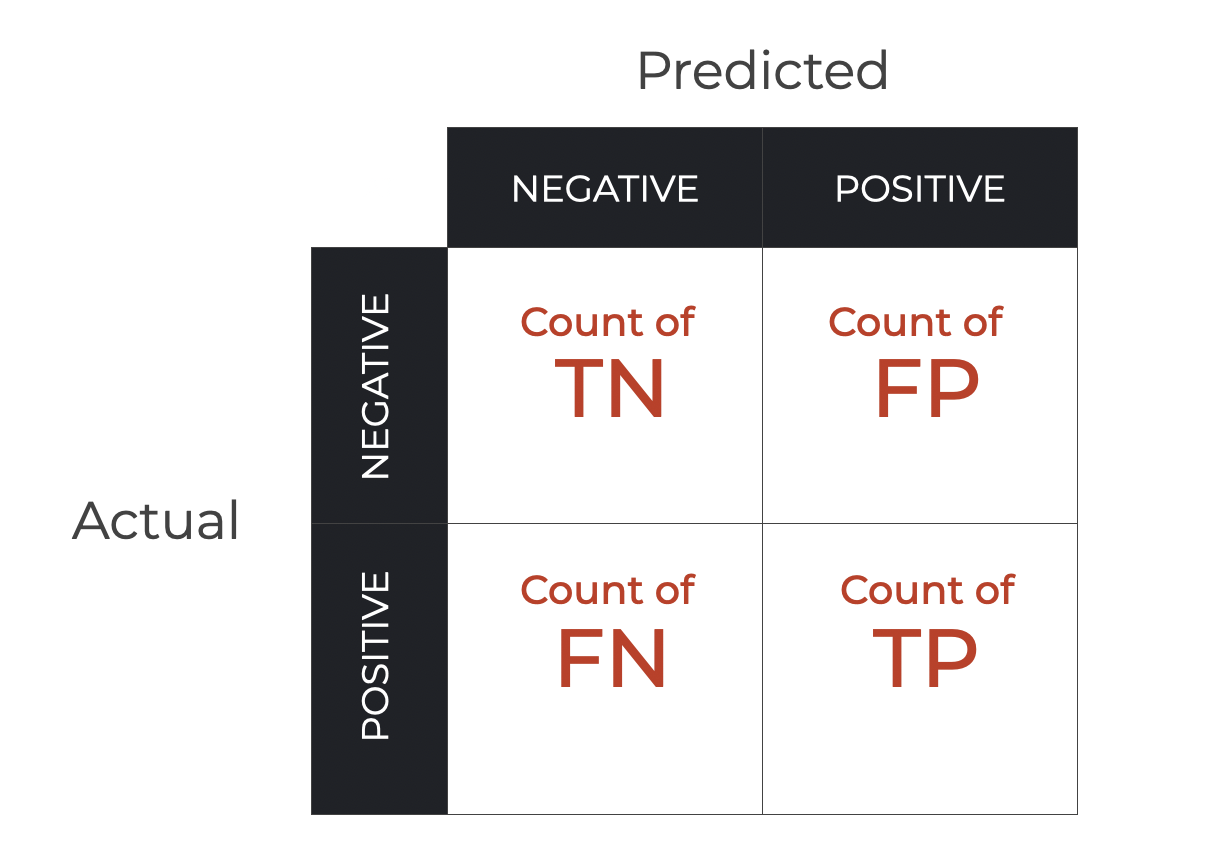

In [17]:
from sklearn.metrics import confusion_matrix

# 예측값
y_pred = best_model.predict(X_test)

# confusion matrix 생성
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[95 15]
 [16 53]]


In [18]:
tn, fp, fn, tp = cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 95
FP: 15
FN: 16
TP: 53


In [19]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall (Sensitivity):", recall)
print("Specificity:", specificity)

Accuracy: 0.8268156424581006
Precision: 0.7794117647058824
Recall (Sensitivity): 0.7681159420289855
Specificity: 0.8636363636363636


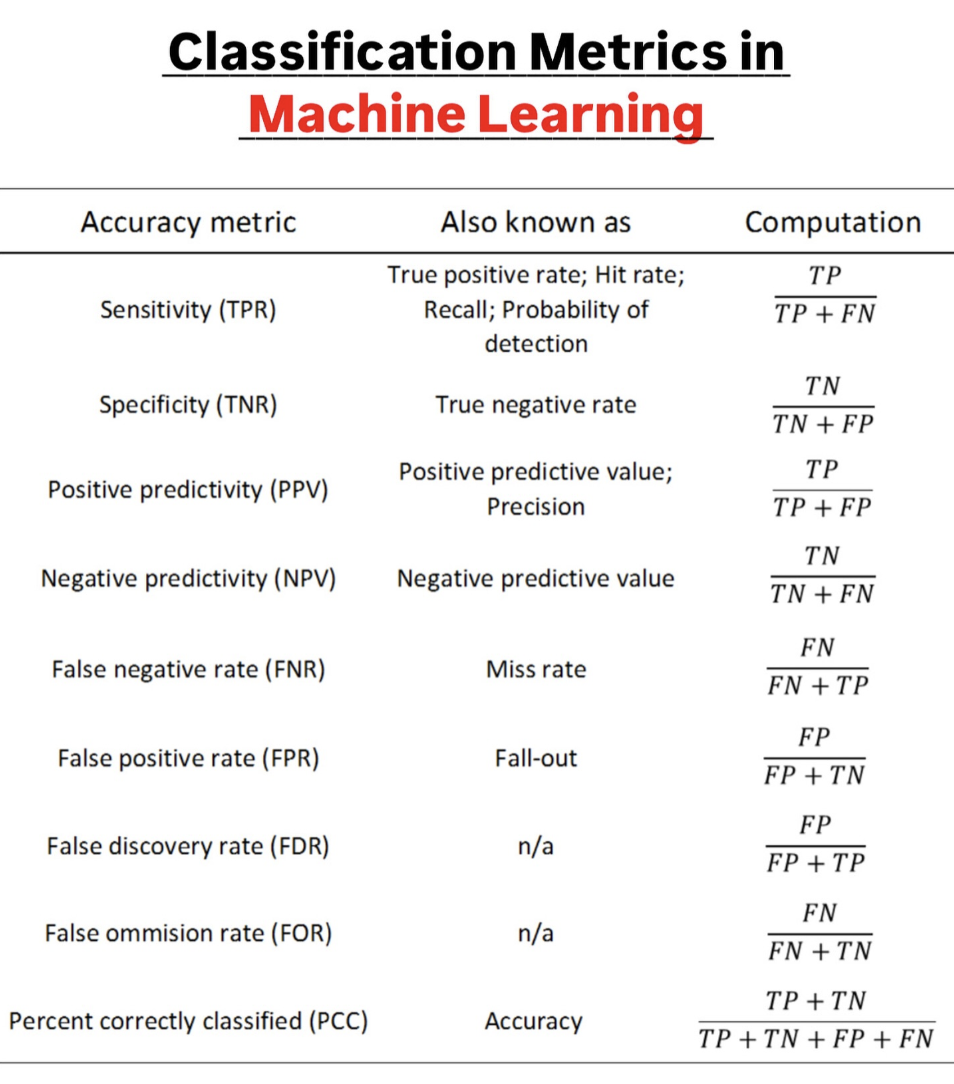

Test ROC AUC: 0.8289196310935443


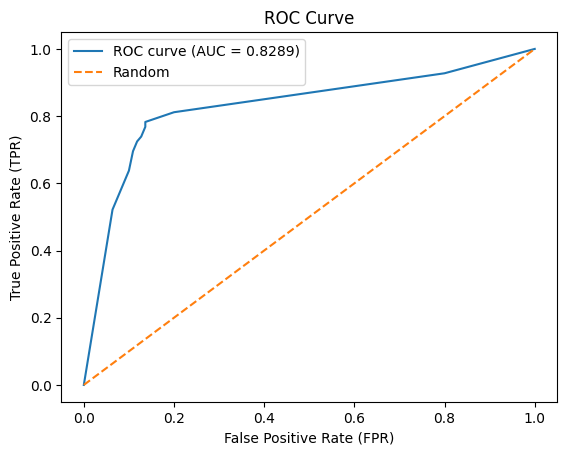

In [20]:
# 10) ROC / AUC (양성 클래스=1 확률 사용)
proba = best_model.predict_proba(X_test)[:, 1]  # Survived=1 확률
auc = roc_auc_score(y_test, proba)
fpr, tpr, thresholds = roc_curve(y_test, proba)

print("Test ROC AUC:", auc)

# ROC Curve Plot
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.show()

## ROC Curve와 AUC는 언제 사용하면 좋을까?
- 데이터가 불균형일 때 (어느정도는 괜찮음, 극단적일땐 PR-AP)
  - Accuracy는 의미 없어질 수 있음
  - AUC는 상대적으로 robust
- 모델을 비교할 때
  - 여러 모델 중 누가 더 “구분 능력”이 좋은지 비교

- 아래와 같은 경우 사용을 굳이 하지 않음
  - 다중 클래스 그대로 사용할 때 (변형 필요)
  - 확률 출력이 없는 모델
  - threshold 자체가 중요한 상황 (예: 의료 cut-off)

## ROC Curve, AUC 사용가능 모델 vs 사용 불가능 모델

- 사용 가능한 모델 예

  LogisticRegression

  RandomForest

  XGBoost

  SVM (probability=True 설정 필요)

  GradientBoosting

  NeuralNet (MLP)

- 바로 못 쓰는 경우

  KMeans (비지도학습)

  PCA

  단순 clustering 모델

  회귀 모델

Test PR Average Precision: 0.7418054618972005


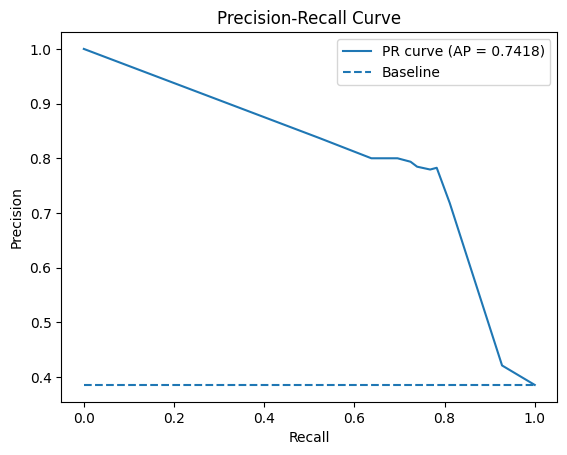

In [22]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# 양성 클래스(=1) 확률
proba = best_model.predict_proba(X_test)[:, 1]

# Average Precision (AP)
ap = average_precision_score(y_test, proba)

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, proba)

print("Test PR Average Precision:", ap)

# PR Curve Plot
plt.figure()
plt.plot(recall, precision, label=f"PR curve (AP = {ap:.4f})")

# baseline (랜덤 모델의 기준선 = 양성 비율)
positive_ratio = y_test.mean()
plt.hlines(positive_ratio, 0, 1, linestyles="--", label="Baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

- “양성 클래스가 매우 중요”할 때


  - 암 진단

  - 사기 탐지

  - 이상 탐지


- FP보다 FN이 더 중요한 게 아니라
“양성 예측의 품질”이 중요

 - 이때는 PR curve가 더 적절하다.

- 10,000개 중 양성 100개 (1%)


  - TP = 60

  - FN = 40

  - FP = 400

  - TN = 9,500


### FPR

400/(400+9500)≈0.04

→ 4%

이 값은 꽤 작다.

그래서 ROC 곡선 상에서는 나쁘지 않아 보인다.

하지만

### Precision

60/(60+400)≈0.13

→ 13%

양성이라고 한 것 중 대부분이 틀림.

현실에서는 꽤 안 좋은 모델인데
ROC-AUC는 괜찮아 보일 수 있다.

# 코로나-19 검사키트와 평가지표

- 코로나 19 검사키트에선 양성이라고 했는데 나는 아무 증상도 없었는데?
- 코로나 19 검사키트에선 음성이라고 했는데 나는 감기 이상으로 심각하게 아팠는데?

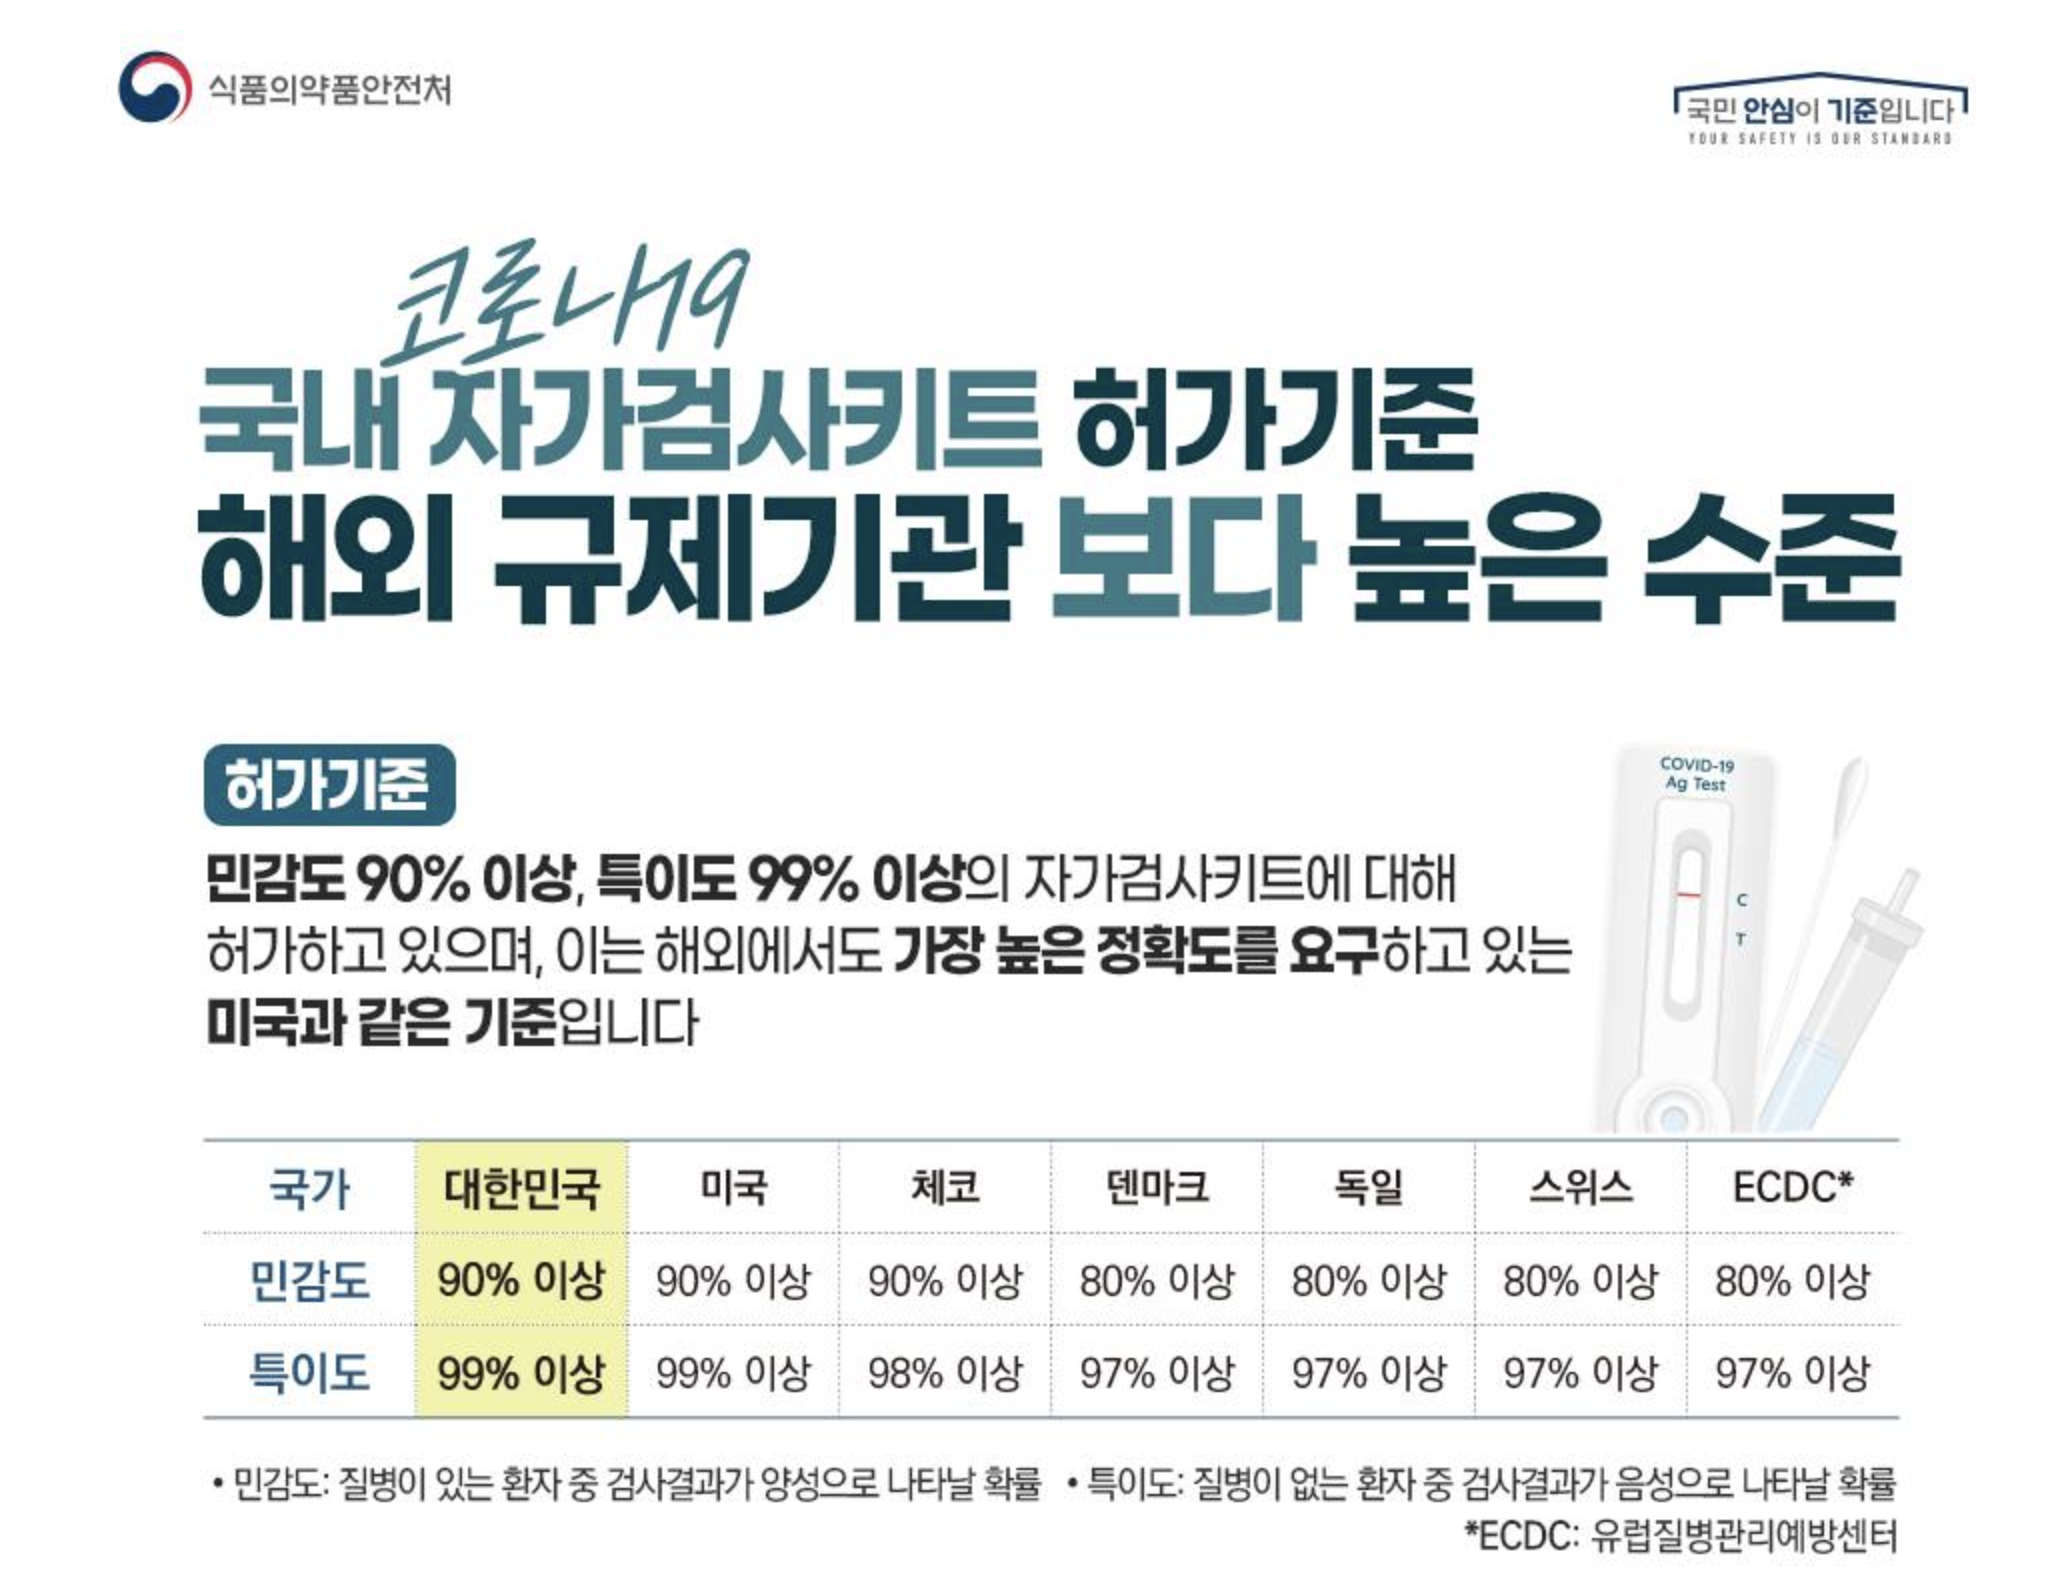

https://www.mfds.go.kr/brd/m_1056/view.do?seq=34&srchFr=&srchTo=&srchWord=&srchTp=&itm_seq_1=0&itm_seq_2=0&multi_itm_seq=0&company_cd=&company_nm=&page=1

## 민감도 (Sensitivity)

→ 실제 감염자 중에서 양성으로 잡아내는 비율

→ 90%면 감염자 100명 중 90명은 양성, 10명은 놓침 (false negative)

## 특이도 (Specificity)

→ 실제 비감염자 중에서 음성으로 판정하는 비율

→ 99%면 비감염자 100명 중 99명은 음성, 1명은 잘못 양성 (false positive)

만약, 유병률 1%라고 가정한다면 (보통 코로나 초기 유병률을 1~2%로 가정)


10,000명을 검사한다고 가정해보자.

감염자 1% → 100명

비감염자 9,900명






- 감염자 100명 중

  90% → 90명 진짜 양성

  10% → 10명 위음성 (false negative)

- 비감염자 9,900명 중

  99% → 9,801명 진짜 음성

  1% → 99명 위양성 (false positive)

양성 판정 189명 중 실제 감염자는 90명뿐
→ 양성 예측도(PPV) ≈ 48%

유병률이 적을 수록 위양성 상대적으로 더 증가

즉, 감염자가 적을수록 위양성이 많아 보인다.

- (유병률 출처) Lavezzo, E. et al. (2020) Suppression of a SARS-CoV-2 outbreak in the Italian municipality of Vo’. Nature https://doi.org/10.1038/s41586-020-2488-1

만약, 유병률 10%라고 가정한다면?
10,000명 검사

감염자 1,000명

비감염자 9,000명

- 감염자

  900명 진짜 양성

  100명 위음성

- 비감염자

  8,910명 진짜 음성
  90명 위양성

이번엔 양성 990명 중 실제 감염자 900명


→ 양성 예측도 ≈ 91%

- 특이도 99%면 위양성은 1% 발생

- 민감도 90%면 위음성은 10% 발생

- 하지만 실제 체감 위험은 유병률에 따라 완전히 달라진다

따라서, 실무적으로는...

- 코로나가 거의 없는 시기에는
→ 양성 나오면 PCR로 재확인 필요 (위양성 많음)

- 코로나가 유행 중일 때는
→ 음성이어도 증상 있으면 재검 필요 (위음성 문제)